In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

In [2]:
df = pd.read_csv('data/california_housing.csv')
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Features
X = df.drop("Price", axis=1)

In [5]:
# Target 
y = df["Price"]

In [6]:
X.shape

(20640, 8)

In [7]:
y.shape

(20640,)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [14]:
print("X_train:\n", X_train.shape)

X_train:
 (14448, 8)


In [15]:
print("X_test:\n", X_test.shape)

X_test:
 (6192, 8)


In [13]:
print("y_train:\n", y_train.shape)

y_train:
 (14448,)


In [16]:
print("y_test:\n", y_test.shape)

y_test:
 (6192,)


In [17]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [18]:
# train 
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [19]:
xgb_pred = xgb_model.predict(X_test)

In [20]:
# Evaluation
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

In [21]:
print("\n===== XGBoost =====")

print("MSE :", xgb_mse)
print("RMSE:", xgb_rmse)
print("MAE :", xgb_mae)
print("R2  :", xgb_r2)


===== XGBoost =====
MSE : 0.20410671148395798
RMSE: 0.45178170777927473
MAE : 0.29999588507434194
R2  : 0.8444948765612097


In [24]:
sns.set_theme(style="darkgrid", palette="pastel")

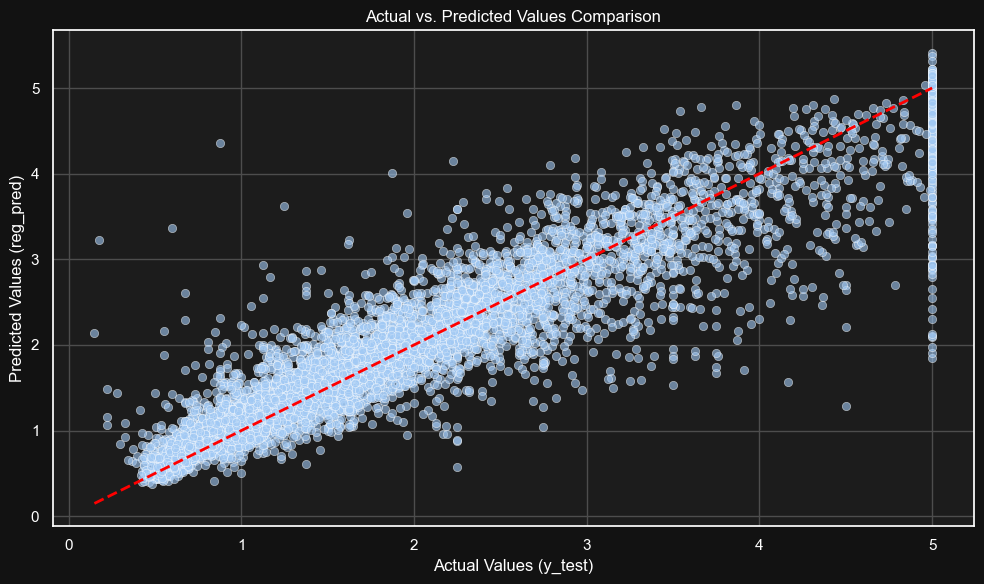

In [33]:
plt.figure(figsize=(10, 6))

# Plot scatter using seaborn
sns.scatterplot(x=y_test, y=xgb_pred, alpha=0.6, color='b', edgecolor='w')

# Plot a reference diagonal line (if predictions are perfect, points will lie on this line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (reg_pred)')
plt.title('Actual vs. Predicted Values Comparison')
plt.tight_layout()
plt.savefig("reports/images/xgboost_results/actual_predicted_scatter.png")
plt.show()

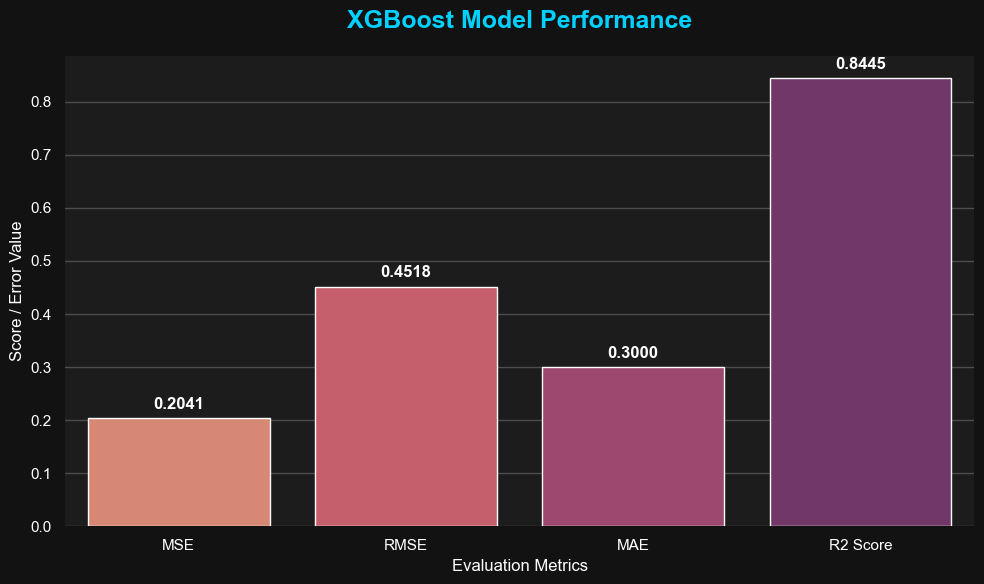

In [35]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

# 2. Chuẩn bị dữ liệu
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2 Score'],
    'Value': [xgb_mse, xgb_rmse, xgb_mae, xgb_r2]
}
df_metrics = pd.DataFrame(metrics_data)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Sử dụng barplot của seaborn với màu sắc hiện đại
ax = sns.barplot(
    x='Metric', 
    y='Value', 
    data=df_metrics, 
    hue='Metric',       # Gán màu theo từng cột
    palette='flare',    # Palette 'flare' hoặc 'viridis' rất đẹp trên nền tối
    legend=False
)

# 4. Thêm số liệu thực tế trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                color='white',
                fontsize=12,
                fontweight='bold')

# Tinh chỉnh tiêu đề
plt.title('XGBoost Model Performance', fontsize=18, fontweight='bold', color='#00d1ff', pad=20)
plt.ylabel('Score / Error Value')
plt.xlabel('Evaluation Metrics')

# Loại bỏ viền thừa
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("reports/images/xgboost_results/performance.png")
plt.show()

# **Residuals**

In [28]:
residuals = y_test - xgb_pred

In [29]:
residuals

20046   -0.043161
3024    -0.493738
15663   -0.158397
20484   -0.274291
9814     0.443351
           ...   
17505    0.235175
13512    0.037883
10842   -0.168884
16559   -0.166581
5786     0.051721
Name: Price, Length: 6192, dtype: float64

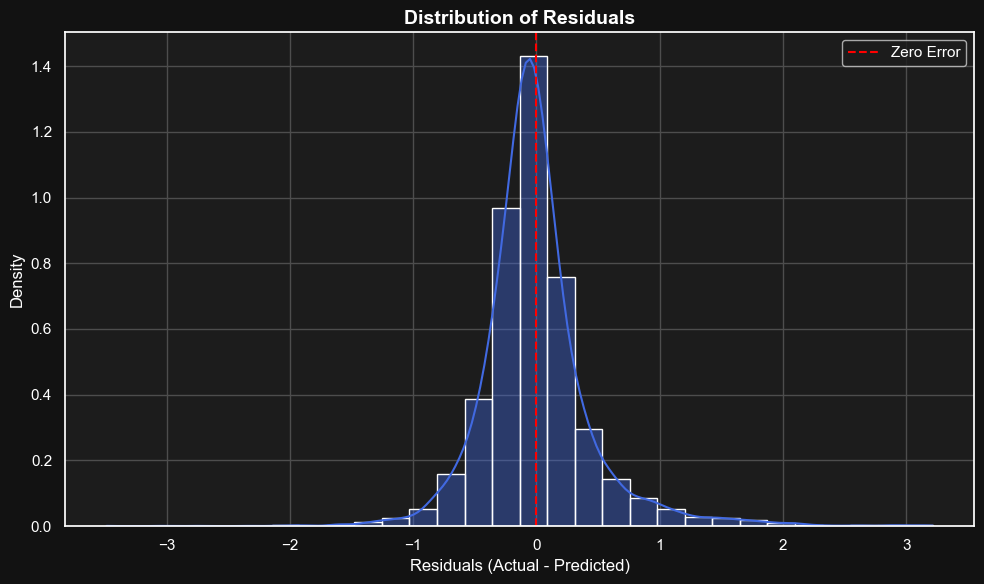

In [36]:
plt.figure(figsize=(10, 6))

# Improve the plot by combining a histogram with a KDE curve
# kde=True: Adds the kernel density estimate line
# stat="density": Normalizes the histogram so the area equals 1
sns.histplot(residuals, kde=True, color='royalblue', bins=30, stat="density", alpha=0.4)

# Add a vertical dashed line at 0
# Ideally, residuals should be normally distributed around zero
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')

# Labeling for clarity
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig("reports/images/xgboost_results/residuals.png")
plt.show()

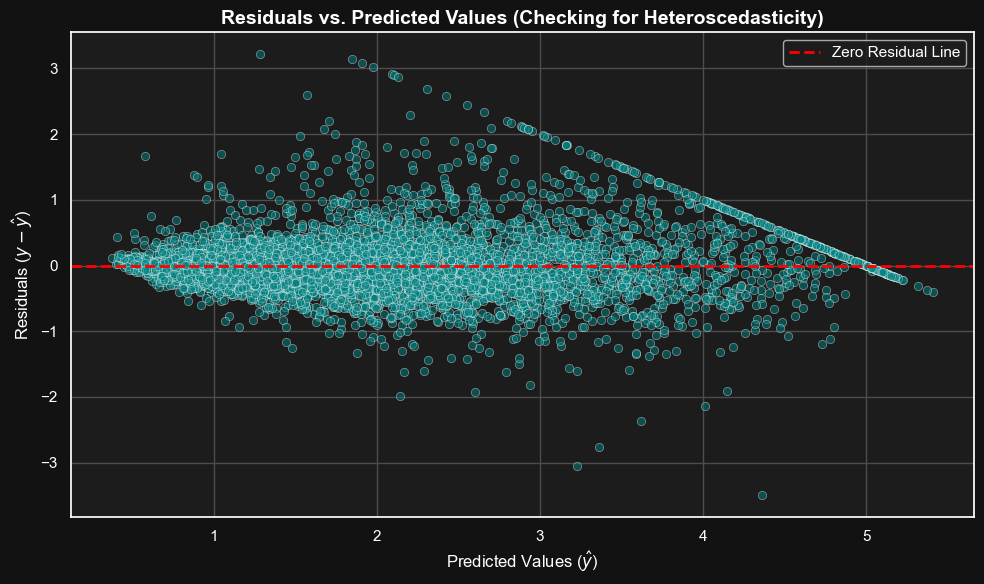

In [42]:
# Scatter plot with respect to prediction and residuals
plt.figure(figsize=(10, 6))

# Use sns.scatterplot for better control over aesthetics
sns.scatterplot(x=xgb_pred, y=residuals, alpha=0.5, color='teal', edgecolor='w')

# Add a horizontal line at y=0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')

# FIX: Use 'r' before the string to avoid SyntaxWarning with LaTeX backslashes
plt.xlabel(r'Predicted Values ($\hat{y}$)', fontsize=12)
plt.ylabel(r'Residuals ($y - \hat{y}$)', fontsize=12)

plt.title('Residuals vs. Predicted Values (Checking for Heteroscedasticity)', fontsize=14, fontweight='bold')
plt.legend()
plt.savefig("reports/images/xgboost_results/prediction_residuals_scatter.png")
plt.tight_layout()
plt.show()

In [38]:
joblib.dump(xgb_model, "models/xgboost_model.pkl")

['models/xgboost_model.pkl']

In [39]:
# Load saved model
xgb_model = joblib.load("models/xgboost_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [41]:
sample = pd.DataFrame({
    "MedInc": [8.3252],
    "HouseAge": [41.0],
    "AveRooms": [6.9841],
    "AveBedrms": [1.0238],
    "Population": [322.0],
    "AveOccup": [2.5556],
    "Latitude": [37.88],
    "Longitude": [-122.23]
})

result = xgb_model.predict(sample)

print("\nPredicted Price:", result[0])


Predicted Price: 4.272719
